BEFORE — Step 1: Data Loading & Noise Cleaning
Shape            : (400, 25)
Total missing    : 1012

dm unique values : ['yes' 'no' '\tno' nan]
cad unique values: ['no' 'yes' nan]

AFTER  — Step 1: Data Loading & Noise Cleaning
Shape            : (400, 25)
Total missing    : 1012

dm unique values : ['yes' 'no' nan]
cad unique values: ['no' 'yes' nan]

Target classes   : {'ckd': 250, 'notckd': 150}


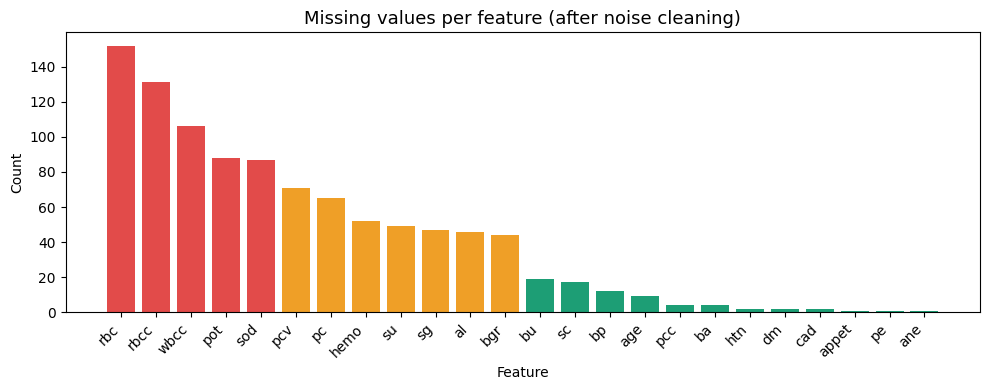

Step 1 complete.


In [5]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load dataset ──────────────────────────────────────────────────────────────
from ucimlrepo import fetch_ucirepo
import pandas as pd

ckd = fetch_ucirepo(id=336)

df = pd.concat([ckd.data.features, ckd.data.targets], axis=1)

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 1: Data Loading & Noise Cleaning')
print('=' * 55)
print(f'Shape            : {df.shape}')
print(f'Total missing    : {df.isnull().sum().sum()}')
print(f'\ndm unique values : {df["dm"].unique()}')
print(f'cad unique values: {df["cad"].unique()}')

# ── NOISE CLEANING ────────────────────────────────────────────────────────────
# 1. Strip whitespace and tabs, lowercase all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

# 2. Replace '?' placeholder (sometimes used in UCI files) with NaN
df.replace('?', np.nan, inplace=True)

# 3. Rename classification column for clarity
if 'classification' in df.columns:
    df.rename(columns={'classification': 'target'}, inplace=True)
elif 'class' in df.columns:
    df.rename(columns={'class': 'target'}, inplace=True)
# ── AFTER ─────────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('AFTER  — Step 1: Data Loading & Noise Cleaning')
print('=' * 55)
print(f'Shape            : {df.shape}')
print(f'Total missing    : {df.isnull().sum().sum()}')
print(f'\ndm unique values : {df["dm"].unique()}')
print(f'cad unique values: {df["cad"].unique()}')
print(f'\nTarget classes   : {df["target"].value_counts().to_dict()}')

# ── VISUALIZE ─────────────────────────────────────────────────────────────────
miss_before = df.isnull().sum()
miss_before = miss_before[miss_before > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#E24B4A' if v > 80 else '#EF9F27' if v > 30 else '#1D9E75' for v in miss_before.values]
ax.bar(miss_before.index, miss_before.values, color=colors, edgecolor='none')
ax.set_title('Missing values per feature (after noise cleaning)', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('step1_missing.png', dpi=120)
plt.show()
print('Step 1 complete.')

BEFORE — Step 2: Numerical Imputation
age       9
bp       12
bgr      44
bu       19
sc       17
sod      87
pot      88
hemo     52
pcv      71
wbcc    106
rbcc    131

Total numerical missing: 636

AFTER  — Step 2: Numerical Imputation
age     0
bp      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wbcc    0
rbcc    0

Total numerical missing: 0


/tmp/ipykernel_16525/1073588424.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


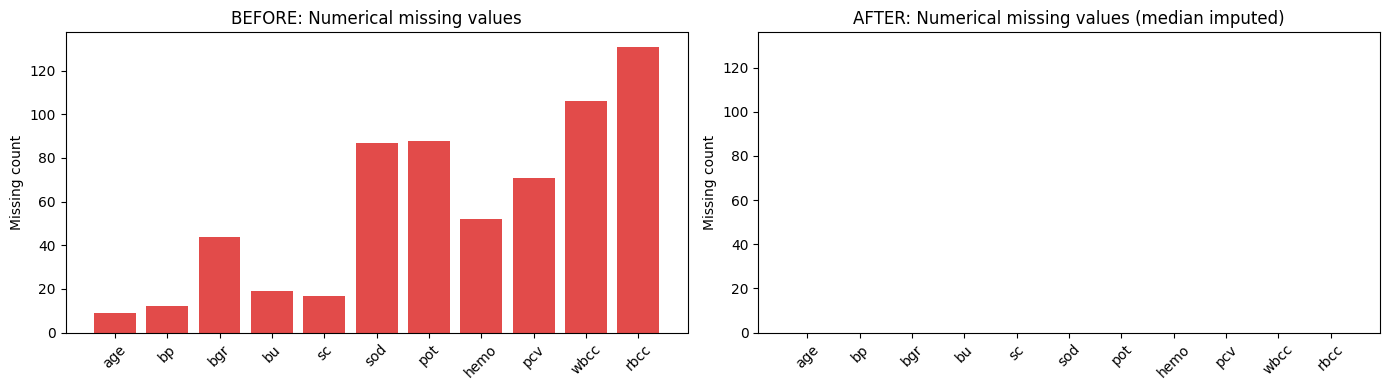


Numerical feature stats after imputation:
          age      bp     bgr      bu      sc     sod     pot    hemo     pcv      wbcc    rbcc
count  400.00  400.00  400.00  400.00  400.00  400.00  400.00  400.00  400.00    400.00  400.00
mean    51.56   76.58  145.06   56.69    3.00  137.63    4.58   12.54   39.08   8298.50    4.74
std     16.98   13.49   75.26   49.40    5.63    9.21    2.82    2.72    8.16   2529.59    0.84
min      2.00   50.00   22.00    1.50    0.40    4.50    2.50    3.10    9.00   2200.00    2.10
25%     42.00   70.00  101.00   27.00    0.90  135.00    4.00   10.88   34.00   6975.00    4.50
50%     55.00   80.00  121.00   42.00    1.30  138.00    4.40   12.65   40.00   8000.00    4.80
75%     64.00   80.00  150.00   61.75    2.72  141.00    4.80   14.62   44.00   9400.00    5.10
max     90.00  180.00  490.00  391.00   76.00  163.00   47.00   17.80   54.00  26400.00    8.00
Step 2 complete.


In [6]:
# ── Identify numerical columns (excluding target) ─────────────────────────────
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

# Convert to float (sometimes read as object due to mixed content)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 2: Numerical Imputation')
print('=' * 55)
before_miss = df[num_cols].isnull().sum()
print(before_miss[before_miss > 0].to_string())
print(f'\nTotal numerical missing: {df[num_cols].isnull().sum().sum()}')

# ── MEDIAN IMPUTATION ─────────────────────────────────────────────────────────
for col in num_cols:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)

# ── AFTER ─────────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('AFTER  — Step 2: Numerical Imputation')
print('=' * 55)
after_miss = df[num_cols].isnull().sum()
print(after_miss.to_string())
print(f'\nTotal numerical missing: {df[num_cols].isnull().sum().sum()}')

# ── VISUALIZE: before vs after missing for numerical cols ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

before_vals = before_miss[before_miss > 0]
axes[0].bar(before_vals.index, before_vals.values, color='#E24B4A', edgecolor='none')
axes[0].set_title('BEFORE: Numerical missing values', fontsize=12)
axes[0].set_ylabel('Missing count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(num_cols, [0]*len(num_cols), color='#1D9E75', edgecolor='none')
axes[1].set_title('AFTER: Numerical missing values (median imputed)', fontsize=12)
axes[1].set_ylabel('Missing count')
axes[1].set_ylim(0, before_vals.max() + 5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('step2_num_imputation.png', dpi=120)
plt.show()

# Show descriptive stats after imputation
print('\nNumerical feature stats after imputation:')
print(df[num_cols].describe().round(2).to_string())
print('Step 2 complete.')

BEFORE — Step 3: Categorical Imputation
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1

Total categorical missing: 376

rbc value counts:
rbc
normal      201
NaN         152
abnormal     47

AFTER  — Step 3: Categorical Imputation
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0

Total categorical missing: 0

rbc value counts:
rbc
normal      353
abnormal     47


/tmp/ipykernel_16525/2267135422.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


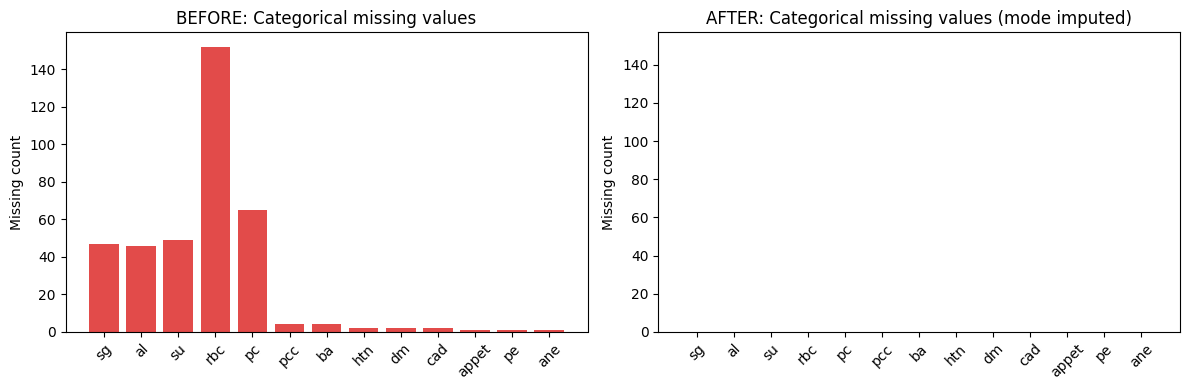


Total missing values remaining: 0
Step 3 complete.


In [7]:
# ── Identify categorical columns (excluding target) ───────────────────────────
cat_cols = ['sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 3: Categorical Imputation')
print('=' * 55)
before_cat_miss = df[cat_cols].isnull().sum()
print(before_cat_miss[before_cat_miss > 0].to_string())
print(f'\nTotal categorical missing: {df[cat_cols].isnull().sum().sum()}')
print(f'\nrbc value counts:\n{df["rbc"].value_counts(dropna=False).to_string()}')

# ── MODE IMPUTATION ───────────────────────────────────────────────────────────
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

# ── AFTER ─────────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('AFTER  — Step 3: Categorical Imputation')
print('=' * 55)
after_cat_miss = df[cat_cols].isnull().sum()
print(after_cat_miss.to_string())
print(f'\nTotal categorical missing: {df[cat_cols].isnull().sum().sum()}')
print(f'\nrbc value counts:\n{df["rbc"].value_counts().to_string()}')

# ── VISUALIZE ─────────────────────────────────────────────────────────────────
before_vals = before_cat_miss[before_cat_miss > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(before_vals.index, before_vals.values, color='#E24B4A', edgecolor='none')
axes[0].set_title('BEFORE: Categorical missing values', fontsize=12)
axes[0].set_ylabel('Missing count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(before_vals.index, [0]*len(before_vals), color='#1D9E75', edgecolor='none')
axes[1].set_title('AFTER: Categorical missing values (mode imputed)', fontsize=12)
axes[1].set_ylabel('Missing count')
axes[1].set_ylim(0, before_vals.max() + 5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('step3_cat_imputation.png', dpi=120)
plt.show()

print(f'\nTotal missing values remaining: {df.isnull().sum().sum()}')
print('Step 3 complete.')

BEFORE — Step 4: Label Encoding
Sample categorical values:
  rbc       : ['normal' 'abnormal']
  pc        : ['normal' 'abnormal']
  htn       : ['yes' 'no']
  dm        : ['yes' 'no']
  appet     : ['good' 'poor']
  target    : ['ckd' 'notckd']

dtypes before encoding:
age       float64
bp        float64
sg        float64
al        float64
su        float64
rbc        object
pc         object
pcc        object
ba         object
bgr       float64
bu        float64
sc        float64
sod       float64
pot       float64
hemo      float64
pcv       float64
wbcc      float64
rbcc      float64
htn        object
dm         object
cad        object
appet      object
pe         object
ane        object
target     object

AFTER  — Step 4: Label Encoding
All dtypes after encoding:
age       float64
bp        float64
sg        float64
al        float64
su        float64
rbc       float64
pc        float64
pcc       float64
ba        float64
bgr       float64
bu        float64
sc        float64
sod

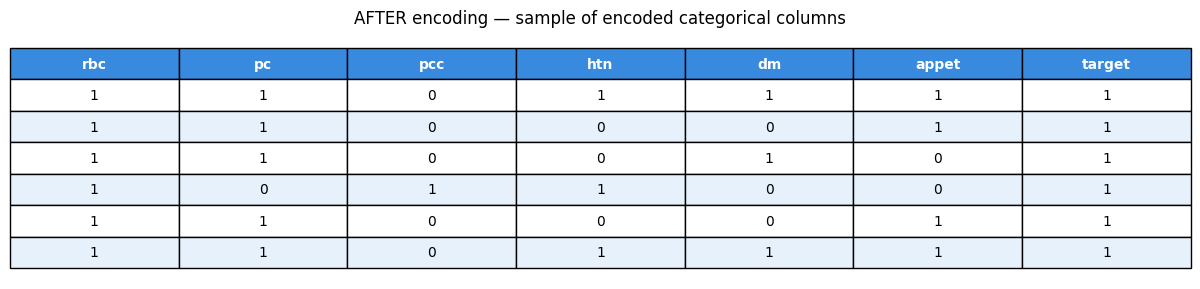

Step 4 complete.


In [8]:
import json

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 4: Label Encoding')
print('=' * 55)
print('Sample categorical values:')
for col in ['rbc', 'pc', 'htn', 'dm', 'appet', 'target']:
    print(f'  {col:10s}: {df[col].unique()}')
print(f'\ndtypes before encoding:\n{df.dtypes.to_string()}')

# ── ENCODING MAPS ─────────────────────────────────────────────────────────────
# Binary yes/no columns
binary_map = {'yes': 1, 'no': 0}
binary_cols = ['htn', 'dm', 'cad', 'pe', 'ane']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# normal/abnormal and present/notpresent columns
df['rbc']  = df['rbc'].map({'normal': 1, 'abnormal': 0})
df['pc']   = df['pc'].map({'normal': 1, 'abnormal': 0})
df['pcc']  = df['pcc'].map({'present': 1, 'notpresent': 0})
df['ba']   = df['ba'].map({'present': 1, 'notpresent': 0})
df['appet'] = df['appet'].map({'good': 1, 'poor': 0})

# Ordinal: sg (specific gravity) — already numeric-like
df['sg'] = pd.to_numeric(df['sg'], errors='coerce')

# Ordinal: al and su (0-5 scale)
df['al'] = pd.to_numeric(df['al'], errors='coerce')
df['su'] = pd.to_numeric(df['su'], errors='coerce')

# Target column
df['target'] = df['target'].map({'ckd': 1, 'notckd': 0})

# Refill any NaN introduced by bad mapping values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

df = df.astype(float)

# ── AFTER ─────────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('AFTER  — Step 4: Label Encoding')
print('=' * 55)
print('All dtypes after encoding:')
print(df.dtypes.to_string())
print(f'\nTarget classes: {df["target"].value_counts().to_dict()}')
print(f'Total missing  : {df.isnull().sum().sum()}')

# ── VISUALIZE: sample rows before vs after ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
preview_cols = ['rbc', 'pc', 'pcc', 'htn', 'dm', 'appet', 'target']
table_data = df[preview_cols].head(6).round(0).astype(int)
tbl = ax.table(cellText=table_data.values,
               colLabels=table_data.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#378ADD')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E6F1FB')
ax.set_title('AFTER encoding — sample of encoded categorical columns', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('step4_encoding.png', dpi=120)
plt.show()
print('Step 4 complete.')

BEFORE — Step 5: Feature Scaling
Feature value ranges:
  age       : min=2.00, max=90.00
  bp        : min=50.00, max=180.00
  sg        : min=1.00, max=1.02
  al        : min=0.00, max=5.00
  su        : min=0.00, max=5.00
  rbc       : min=0.00, max=1.00
  pc        : min=0.00, max=1.00
  pcc       : min=0.00, max=1.00
  ba        : min=0.00, max=1.00
  bgr       : min=22.00, max=490.00
  bu        : min=1.50, max=391.00
  sc        : min=0.40, max=76.00
  sod       : min=4.50, max=163.00
  pot       : min=2.50, max=47.00
  hemo      : min=3.10, max=17.80
  pcv       : min=9.00, max=54.00
  wbcc      : min=2200.00, max=26400.00
  rbcc      : min=2.10, max=8.00
  htn       : min=0.00, max=1.00
  dm        : min=0.00, max=1.00
  cad       : min=0.00, max=1.00
  appet     : min=0.00, max=1.00
  pe        : min=0.00, max=1.00
  ane       : min=0.00, max=1.00

AFTER  — Step 5: Feature Scaling
Feature value ranges after scaling:
  age       : min=0.00, max=1.00
  bp        : min=0.00, max=

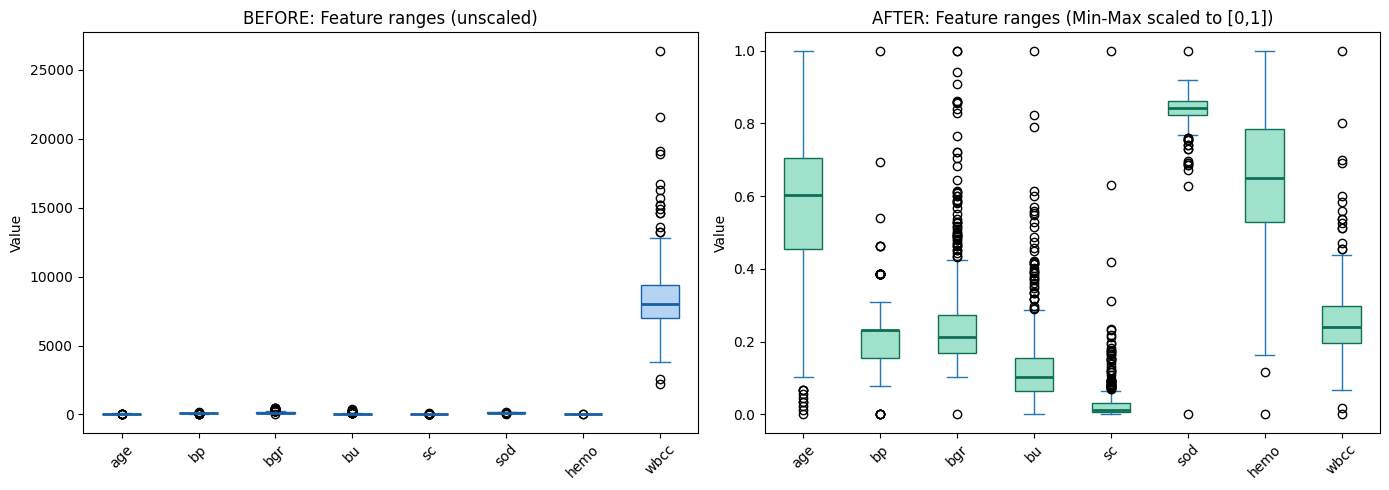

Step 5 complete.


In [9]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 5: Feature Scaling')
print('=' * 55)
print('Feature value ranges:')
for col in X.columns:
    print(f'  {col:10s}: min={X[col].min():.2f}, max={X[col].max():.2f}')

# ── MIN-MAX SCALING ───────────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── AFTER ─────────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('AFTER  — Step 5: Feature Scaling')
print('=' * 55)
print('Feature value ranges after scaling:')
for col in X_scaled.columns:
    print(f'  {col:10s}: min={X_scaled[col].min():.2f}, max={X_scaled[col].max():.2f}')

# ── VISUALIZE: boxplots before vs after for key numerical features ─────────────
key_num = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'wbcc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X[key_num].plot(kind='box', ax=axes[0], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#185FA5', linewidth=2))
axes[0].set_title('BEFORE: Feature ranges (unscaled)', fontsize=12)
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

X_scaled[key_num].plot(kind='box', ax=axes[1], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#9FE1CB', color='#0F6E56'),
                       medianprops=dict(color='#0F6E56', linewidth=2))
axes[1].set_title('AFTER: Feature ranges (Min-Max scaled to [0,1])', fontsize=12)
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('step5_scaling.png', dpi=120)
plt.show()
print('Step 5 complete.')

BEFORE — Step 6: Class Imbalance Handling (SMOTE)
Class distribution:
  CKD     (1): 250 samples (62.5%)
  Not CKD (0): 150 samples (37.5%)
  Total      : 400
  Imbalance ratio: 1.67:1

AFTER  — Step 6: Class Imbalance Handling (SMOTE)
Class distribution:
  CKD     (1): 250 samples (50.0%)
  Not CKD (0): 250 samples (50.0%)
  Total      : 500
  Imbalance ratio: 1.00:1


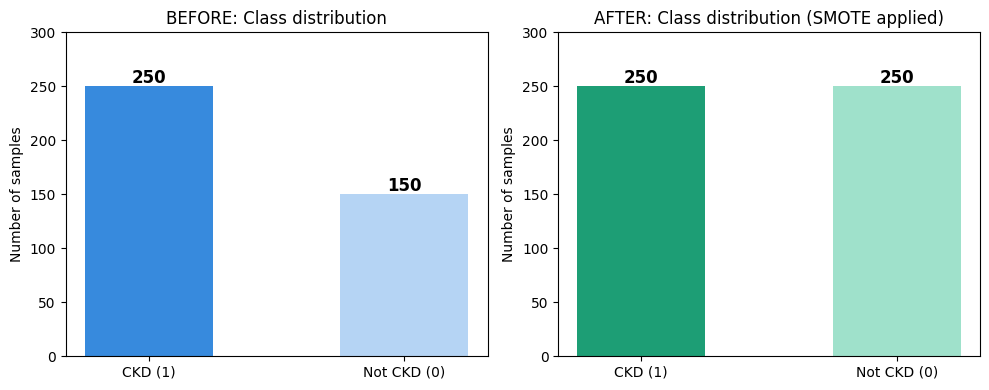

Step 6 complete.


In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# ── BEFORE ────────────────────────────────────────────────────────────────────
print('=' * 55)
print('BEFORE — Step 6: Class Imbalance Handling (SMOTE)')
print('=' * 55)
before_dist = Counter(y.astype(int))
total_before = sum(before_dist.values())
print(f'Class distribution:')
print(f'  CKD     (1): {before_dist[1]} samples ({before_dist[1]/total_before*100:.1f}%)')
print(f'  Not CKD (0): {before_dist[0]} samples ({before_dist[0]/total_before*100:.1f}%)')
print(f'  Total      : {total_before}')
print(f'  Imbalance ratio: {before_dist[1]/before_dist[0]:.2f}:1')

# ── APPLY SMOTE ───────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y.astype(int))

# Convert back to DataFrames
X_final = pd.DataFrame(X_resampled, columns=X_scaled.columns)
y_final = pd.Series(y_resampled, name='target')

# ── AFTER ─────────────────────────────────────────────────────────────────────
after_dist = Counter(y_resampled)
total_after = sum(after_dist.values())
print()
print('=' * 55)
print('AFTER  — Step 6: Class Imbalance Handling (SMOTE)')
print('=' * 55)
print(f'Class distribution:')
print(f'  CKD     (1): {after_dist[1]} samples ({after_dist[1]/total_after*100:.1f}%)')
print(f'  Not CKD (0): {after_dist[0]} samples ({after_dist[0]/total_after*100:.1f}%)')
print(f'  Total      : {total_after}')
print(f'  Imbalance ratio: {after_dist[1]/after_dist[0]:.2f}:1')

# ── VISUALIZE: class distribution before vs after ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels  = ['CKD (1)', 'Not CKD (0)']
before_vals = [before_dist[1], before_dist[0]]
after_vals  = [after_dist[1],  after_dist[0]]
colors_b = ['#378ADD', '#B5D4F4']
colors_a = ['#1D9E75', '#9FE1CB']

axes[0].bar(labels, before_vals, color=colors_b, edgecolor='none', width=0.5)
for i, v in enumerate(before_vals):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('BEFORE: Class distribution', fontsize=12)
axes[0].set_ylabel('Number of samples')
axes[0].set_ylim(0, max(before_vals) * 1.2)

axes[1].bar(labels, after_vals, color=colors_a, edgecolor='none', width=0.5)
for i, v in enumerate(after_vals):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('AFTER: Class distribution (SMOTE applied)', fontsize=12)
axes[1].set_ylabel('Number of samples')
axes[1].set_ylim(0, max(after_vals) * 1.2)

plt.tight_layout()
plt.savefig('step6_smote.png', dpi=120)
plt.show()

print('Step 6 complete.')

In [11]:
print('=' * 60)
print('FULL PREPROCESSING PIPELINE — SUMMARY')
print('=' * 60)

summary = {
    'Step': ['1 — Noise cleaning', '2 — Numerical imputation',
             '3 — Categorical imputation', '4 — Label encoding',
             '5 — Min-Max scaling', '6 — SMOTE'],
    'Problem addressed': [
        'Inconsistent string entries (\\tyes, spaces)',
        'Missing values in 11 numerical features',
        'Missing values in 13 categorical features',
        'String categories incompatible with ML models',
        'Large feature range disparities (0.4 to 26,000)',
        'Class imbalance (250 CKD vs 150 not-CKD)'
    ],
    'Result': [
        'All strings clean and lowercase',
        '0 numerical missing values',
        '0 categorical missing values',
        'All features encoded as float',
        'All features in [0, 1] range',
        'Balanced: 250 CKD / 250 not-CKD'
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print(f'\nFinal dataset shape : {X_final.shape[0]} samples x {X_final.shape[1]} features')
print(f'Final target dist   : {Counter(y_final.values)}')
print(f'Any missing values  : {X_final.isnull().sum().sum()}')
print(f'Feature range check : min={X_final.values.min():.4f}, max={X_final.values.max():.4f}')

print('\nPreprocessing pipeline complete. X_final and y_final are ready for model training.')

FULL PREPROCESSING PIPELINE — SUMMARY
                      Step                               Problem addressed                          Result
        1 — Noise cleaning     Inconsistent string entries (\tyes, spaces) All strings clean and lowercase
  2 — Numerical imputation         Missing values in 11 numerical features      0 numerical missing values
3 — Categorical imputation       Missing values in 13 categorical features    0 categorical missing values
        4 — Label encoding   String categories incompatible with ML models   All features encoded as float
       5 — Min-Max scaling Large feature range disparities (0.4 to 26,000)    All features in [0, 1] range
                 6 — SMOTE        Class imbalance (250 CKD vs 150 not-CKD) Balanced: 250 CKD / 250 not-CKD

Final dataset shape : 500 samples x 24 features
Final target dist   : Counter({np.int64(1): 250, np.int64(0): 250})
Any missing values  : 0
Feature range check : min=0.0000, max=1.0000

Preprocessing pipeline com

In [12]:
!pip install ucimlrepo